# LH Nautical — Etapa 6: Sistema de Recomendação

**Objetivo:** Construir um sistema de recomendação de produtos para os clientes da LH Nautical, usando três abordagens complementares.

**Abordagens implementadas:**
| Abordagem | Lógica |
|---|---|
| **User-Based CF** | Clientes com perfil de compra similar → recomenda o que similares compraram e o alvo não |
| **Item-Based CF** | "Quem comprou X também comprou Y" → similaridade entre produtos |
| **Content-Based** | Recomenda produtos da categoria mais comprada pelo cliente, com maior receita média |

**Ferramentas:** pandas, scikit-learn (cosine_similarity) — sem bibliotecas especializadas, para expor o mecanismo.

## 0. Setup

### Como Executar Este Notebook
1. Execute as células em ordem, do topo ao fim.
2. Este notebook lê as tabelas `gold_fct_vendas`, `silver_produtos` e `silver_clientes` do Delta Lake.
3. As recomendações usam três abordagens (user-based, item-based e content-based).
4. Ao final, rode a célula de checks para validar cobertura e consistência do recomendador.

In [0]:
%pip install scikit-learn -q


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# ── Compatibilidade: Databricks Runtime (UI) vs databricks-connect (VS Code) ─
try:
    spark  # já definido no Databricks runtime
    dbutils.widgets.text("catalog", "workspace",   "Catalog")
    dbutils.widgets.text("schema",  "lh_nautical", "Schema")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA  = dbutils.widgets.get("schema")
except NameError:
    from databricks.connect import DatabricksSession
    spark   = DatabricksSession.builder.serverless().getOrCreate()
    CATALOG = "workspace"
    SCHEMA  = "lh_nautical"

vendas_gold = spark.table(f"{CATALOG}.{SCHEMA}.gold_fct_vendas").toPandas()
vendas_gold["sale_date"] = pd.to_datetime(vendas_gold["sale_date"])

produtos = spark.table(f"{CATALOG}.{SCHEMA}.silver_produtos").toPandas()
clientes = spark.table(f"{CATALOG}.{SCHEMA}.silver_clientes").toPandas()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"

print(f"vendas_gold: {len(vendas_gold):,} | produtos: {len(produtos)} | clientes: {len(clientes)}")

# PARAM: TOP_K e N_SIMILARES (recomendacao)
# TOP_K=5: numero de produtos recomendados por cliente.
#   5 e padrao em sistemas de recomendacao (Netflix, Amazon) — equilibra cobertura e foco.
#   Faixa razoavel: 3-10. >10 perde foco em cross-sell efetivo.
# N_SIMILARES=5: numero de vizinhos no User-Based CF.
#   5 e razoavel para n=49 clientes (~10% da base).
#   Faixa razoavel: 3-10 (>10 dilui o sinal de similaridade neste tamanho de base).
# Nota: estas constantes sao referenciadas como defaults em recomendar_user_based(),
# recomendar_item_based(), recomendar_content_based(), recomendar_content_margem()
# e nas funcoes _eval correspondentes. Alterar aqui requer revisao manual desses defaults.
TOP_K = 5
N_SIMILARES = 5
print("Setup concluido.")
# Safe display — evita erro do Databricks com DataFrame vazio
def safe_print(df):
    if df is not None and not df.empty:
        print(df.to_string(index=False))
    else:
        print('  (sem registros)')

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
vendas_gold: 9,895 | produtos: 150 | clientes: 49
Setup concluido.


In [0]:
# ── Catálogo Delta Lake disponível ──────────────────────────────────────────
spark.sql("SHOW TABLES IN workspace.lh_nautical").show(truncate=False)

+-----------+--------------------+-----------+
|database   |tableName           |isTemporary|
+-----------+--------------------+-----------+
|lh_nautical|bronze_clientes     |false      |
|lh_nautical|bronze_custos       |false      |
|lh_nautical|bronze_produtos     |false      |
|lh_nautical|bronze_vendas       |false      |
|lh_nautical|gold_fct_vendas     |false      |
|lh_nautical|silver_cambio       |false      |
|lh_nautical|silver_clientes     |false      |
|lh_nautical|silver_custos       |false      |
|lh_nautical|silver_produtos     |false      |
|lh_nautical|silver_vendas       |false      |
|lh_nautical|vwp_kpis_cliente    |false      |
|lh_nautical|vwp_kpis_mensal     |false      |
|lh_nautical|vwp_kpis_produto    |false      |
|lh_nautical|vwp_resumo_executivo|false      |
+-----------+--------------------+-----------+



In [0]:
# Margem média por produto — consumindo diretamente a Camada Ouro
margem_produto = spark.sql("""
    SELECT
        v.id_product      AS produto_id,
        p.name            AS produto_nome,
        p.actual_category AS categoria,
        ROUND(SUM(v.lucro) / SUM(v.total) * 100, 1) AS margem_pct
    FROM workspace.lh_nautical.gold_fct_vendas v
    JOIN workspace.lh_nautical.silver_produtos p ON v.id_product = p.id_product
    GROUP BY v.id_product, p.name, p.actual_category
""").toPandas()

margem_produto['status'] = margem_produto['margem_pct'].apply(
    lambda m: 'positiva' if m >= 0 else ('risco' if m >= -5 else 'negativa')
)

def enriquecer_com_margem(df_rec: pd.DataFrame) -> pd.DataFrame:
    """Adiciona margem_pct e status de margem às recomendações."""
    if df_rec.empty:
        for col in ['margem_pct', 'status']:
            df_rec[col] = pd.Series(dtype='object')
        return df_rec
    return df_rec.merge(
        margem_produto[['produto_id', 'margem_pct', 'status']],
        on='produto_id', how='left'
    )

print('Perfil de margem do catálogo (150 produtos):')
print(margem_produto['status'].value_counts().to_string())
print(f'\nMargem média: {margem_produto["margem_pct"].mean():.1f}%')
print(f'Produto com maior margem : {margem_produto.nlargest(1, "margem_pct")["produto_nome"].values[0]}')
print(f'Produto com menor margem : {margem_produto.nsmallest(1, "margem_pct")["produto_nome"].values[0]}')
print('\nmargem_produto pronto. enriquecer_com_margem() disponível.')

Perfil de margem do catálogo (150 produtos):
risco       75
negativa    51
positiva    24

Margem média: -4.4%
Produto com maior margem : Boia de Arqueamento Danforth Torque
Produto com menor margem : Motor de Popa Volvo Hydro Dash 256HP

margem_produto pronto. enriquecer_com_margem() disponível.


## 1. Matriz Cliente-Produto

A base de todo sistema de recomendação colaborativo é uma **matriz de interações**: linhas = clientes, colunas = produtos, valores = sinal de interação.

Usamos a **receita total** de cada par cliente-produto como sinal de intensidade de preferência. Valores zero indicam que o cliente nunca comprou aquele produto.

In [0]:
# Agrega receita total por par cliente-produto consumindo a Camada Ouro
interacoes = spark.sql("""
    SELECT
        v.id_client                     AS cliente_id,
        c.full_name                     AS cliente_nome,
        v.id_product                    AS produto_id,
        p.name                          AS produto_nome,
        p.actual_category               AS categoria,
        ROUND(SUM(v.total), 2)          AS receita_total,
        COUNT(*)                        AS qtd_compras
    FROM workspace.lh_nautical.gold_fct_vendas v
    JOIN workspace.lh_nautical.silver_clientes c ON v.id_client  = c.id_client
    JOIN workspace.lh_nautical.silver_produtos p ON v.id_product = p.id_product
    GROUP BY v.id_client, c.full_name, v.id_product, p.name, p.actual_category
""").toPandas()

print(f'Pares únicos cliente-produto: {len(interacoes)}')
print(f'Total possível: {interacoes["cliente_id"].nunique()} clientes × {interacoes["produto_id"].nunique()} produtos = {interacoes["cliente_id"].nunique() * interacoes["produto_id"].nunique()}')
print(interacoes.head().to_string(index=False))

Pares únicos cliente-produto: 5413
Total possível: 49 clientes × 150 produtos = 7350
 cliente_id                               cliente_nome  produto_id                                produto_nome categoria  receita_total  qtd_compras
         19          Renata Lima Gomes Coelho Mendonça          62           Motor Diesel Yanmar Velocity 37HP propulsão      102222.00            1
         21       Sandra Rocha Oliveira Soares Peixoto         117            Corrente Danforth Zen Abyss Axis ancoragem       19489.25            1
          2       Fernanda Azevedo Soares Nunes Vieira          91 Motor Elétrico Tohatsu Zenith Oceanic 113HP propulsão     1746773.70            2
          6 Antônia Coelho Pinheiro Peixoto Cavalcanti         113                     Âncora Delta Mako Ultra ancoragem      132288.50            3
          1                 Femininos Oliveira Antunes          56 Motor Elétrico Torqeedo Velocity Swift 74HP propulsão     1117708.20            4


Dimensões da matriz: 49 clientes × 150 produtos
Densidade: 73.6% dos pares têm pelo menos uma compra


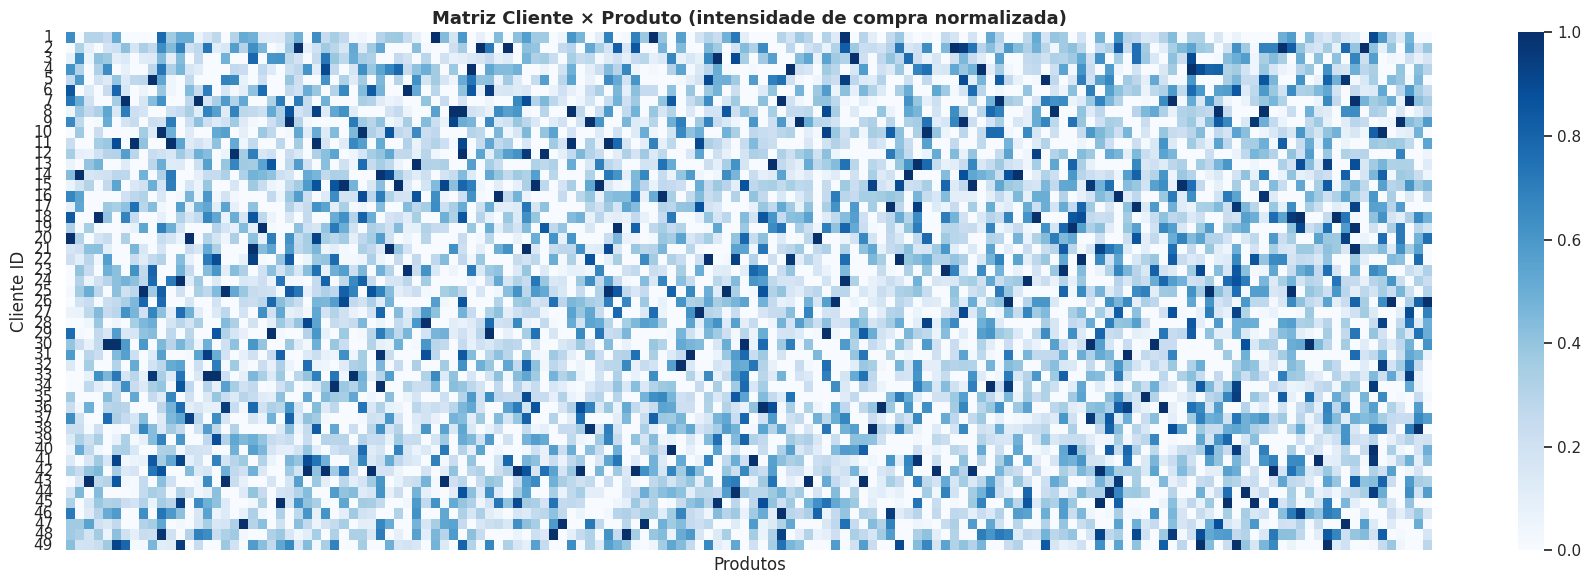

In [0]:
# Constrói a matriz cliente × produto (pivot)
# Valores: receita total — NaN substituído por 0 (nunca comprou)
matriz = interacoes.pivot_table(
    index='cliente_id',
    columns='produto_id',
    values='receita_total',
    aggfunc='sum'
).fillna(0)

# Densidade: % de pares com pelo menos uma compra
densidade = (matriz > 0).sum().sum() / (matriz.shape[0] * matriz.shape[1]) * 100
print(f'Dimensões da matriz: {matriz.shape[0]} clientes × {matriz.shape[1]} produtos')
print(f'Densidade: {densidade:.1f}% dos pares têm pelo menos uma compra')

# Heatmap da matriz (normalizada para visualização)
matriz_norm = MinMaxScaler().fit_transform(matriz)
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(matriz_norm, ax=ax, cmap='Blues', xticklabels=False,
            yticklabels=matriz.index, linewidths=0)
ax.set_title('Matriz Cliente × Produto (intensidade de compra normalizada)', fontsize=13, fontweight='bold')
ax.set_xlabel('Produtos')
ax.set_ylabel('Cliente ID')
plt.tight_layout()
plt.show()

## 2. User-Based Collaborative Filtering

**Lógica:** calculamos a similaridade entre todos os pares de clientes usando **cosine similarity** sobre os vetores de compra. Para cada cliente, encontramos os N mais similares e recomendamos produtos que esses similares compraram mas o cliente-alvo não.

In [0]:
# Matriz de similaridade entre clientes
sim_clientes = cosine_similarity(matriz)
df_sim_clientes = pd.DataFrame(
    sim_clientes,
    index=matriz.index,
    columns=matriz.index
)

print('Matriz de similaridade entre clientes (amostra 5×5):')
print(df_sim_clientes.iloc[:5, :5].round(3).to_string(index=False))

Matriz de similaridade entre clientes (amostra 5×5):
    1     2     3     4     5
1.000 0.560 0.556 0.428 0.580
0.560 1.000 0.526 0.607 0.660
0.556 0.526 1.000 0.476 0.581
0.428 0.607 0.476 1.000 0.460
0.580 0.660 0.581 0.460 1.000


In [0]:
def recomendar_user_based(cliente_id: int, n_similares: int = 5, top_n: int = 5) -> pd.DataFrame:
    """
    Recomenda produtos via User-Based Collaborative Filtering.

    Parâmetros
    ----------
    cliente_id  : ID do cliente-alvo
    n_similares : quantos clientes similares considerar
    top_n       : quantos produtos recomendar

    Retorna
    -------
    DataFrame com produtos recomendados e score de recomendação
    """
    if cliente_id not in df_sim_clientes.index:
        return pd.DataFrame(columns=['produto_id', 'score'])

    # Clientes mais similares (excluindo o próprio)
    similares = (
        df_sim_clientes[cliente_id]
        .drop(cliente_id)
        .sort_values(ascending=False)
        .head(n_similares)
    )

    # Produtos que o cliente-alvo JÁ comprou
    ja_comprados = set(matriz.columns[matriz.loc[cliente_id] > 0])

    # Score ponderado: similaridade × receita dos similares em cada produto
    scores = {}
    for sim_id, sim_score in similares.items():
        for produto_id in matriz.columns:
            if produto_id not in ja_comprados:
                valor = matriz.loc[sim_id, produto_id]
                if valor > 0:
                    scores[produto_id] = scores.get(produto_id, 0) + sim_score * valor

    if not scores:
        return pd.DataFrame(columns=['produto_id', 'score'])

    recomendacoes = (
        pd.DataFrame.from_dict(scores, orient='index', columns=['score'])
        .sort_values('score', ascending=False)
        .head(top_n)
        .reset_index()
        .rename(columns={'index': 'produto_id'})
    )

    # Enriquece com nome e categoria do produto
    mapa_produtos = interacoes[['produto_id', 'produto_nome', 'categoria']].drop_duplicates()
    return recomendacoes.merge(mapa_produtos, on='produto_id', how='left')


# Exemplo: recomendações para o cliente de maior receita (Márcia Figueiredo — ID 42)
print('=== RECOMENDAÇÕES USER-BASED — Márcia Figueiredo (ID 42) ===')
print(recomendar_user_based(42).to_string(index=False))

=== RECOMENDAÇÕES USER-BASED — Márcia Figueiredo (ID 42) ===
 produto_id        score                               produto_nome categoria
         72 3.680084e+06       Motor de Popa Volvo Hydro Dash 256HP propulsão
         97 3.161511e+06            Motor de Popa Tohatsu Evo 168HP propulsão
         71 2.919592e+06        Motor Elétrico Torqeedo Pulse 300HP propulsão
         58 2.794806e+06 Motor de Popa Tohatsu Ion Core Nautic 53HP propulsão
         92 1.692337e+06  Motor Elétrico Yamaha Nautic Kraken 133HP propulsão


## 3. Item-Based Collaborative Filtering

**Lógica:** em vez de comparar clientes, comparamos **produtos** pelo padrão de quem os comprou. Se os mesmos clientes tendem a comprar X e Y juntos, X e Y são similares. Para recomendar, dado um produto que o cliente comprou, sugerimos os produtos mais similares que ele ainda não comprou.

In [0]:
# Transpõe a matriz: agora linhas = produtos, colunas = clientes
sim_produtos = cosine_similarity(matriz.T)
df_sim_produtos = pd.DataFrame(
    sim_produtos,
    index=matriz.columns,
    columns=matriz.columns
)

def recomendar_item_based(cliente_id: int, top_n: int = 5) -> pd.DataFrame:
    """
    Recomenda produtos via Item-Based Collaborative Filtering.

    Para cada produto comprado pelo cliente, acumula score de similaridade
    com produtos ainda não comprados. Recomenda os de maior score.
    """
    if cliente_id not in matriz.index:
        return pd.DataFrame()

    comprados     = matriz.columns[matriz.loc[cliente_id] > 0]
    nao_comprados = matriz.columns[matriz.loc[cliente_id] == 0]

    # Score: soma das similaridades com cada produto já comprado,
    # ponderada pela receita que o cliente gerou naquele produto
    scores = {}
    for prod_nc in nao_comprados:
        score = sum(
            df_sim_produtos.loc[prod_nc, prod_c] * matriz.loc[cliente_id, prod_c]
            for prod_c in comprados
        )
        scores[prod_nc] = score

    recomendacoes = (
        pd.DataFrame.from_dict(scores, orient='index', columns=['score'])
        .sort_values('score', ascending=False)
        .head(top_n)
        .reset_index()
        .rename(columns={'index': 'produto_id'})
    )

    mapa_produtos = interacoes[['produto_id', 'produto_nome', 'categoria']].drop_duplicates()
    return recomendacoes.merge(mapa_produtos, on='produto_id', how='left')


print('=== RECOMENDAÇÕES ITEM-BASED — Márcia Figueiredo (ID 42) ===')
print(recomendar_item_based(42).to_string(index=False))

=== RECOMENDAÇÕES ITEM-BASED — Márcia Figueiredo (ID 42) ===
 produto_id        score                               produto_nome   categoria
         44 3.886094e+07                  GPS Simrad Zen Hydra Peak eletrônicos
        130 3.757610e+07 Boia de Arqueamento Delta Zen Boost Vortex   ancoragem
         71 3.734601e+07        Motor Elétrico Torqeedo Pulse 300HP   propulsão
        102 3.659710e+07                  Cabo de Nylon Bruce Nexus   ancoragem
        109 3.647876e+07       Cabo de Nylon Danforth Evo Aqua Mako   ancoragem


## 4. Content-Based Filtering

**Lógica:** ignora o comportamento de outros clientes — recomenda com base nas características dos produtos que o cliente já comprou.

É útil quando o histórico de outros clientes é insuficiente para gerar recomendações confiáveis — por exemplo, em datasets esparsos, com muitos itens novos, ou para clientes com poucas compras (*cold start* real). Neste dataset com densidade de 73,6%, todas as três abordagens têm cobertura total; o Content-Based se diferencia pela **flexibilidade de critério de ordenação**: aqui usamos popularidade geral, mas a variante na Seção 7 troca esse critério por margem — tornando-o a abordagem mais adaptável a objetivos de negócio.

Aqui usamos **categoria** como feature principal: identificamos a categoria favorita do cliente e recomendamos os produtos dessa categoria que ele ainda não comprou, ordenados pela receita média gerada por outros clientes.

In [0]:
# Receita média por produto entre todos os clientes (popularidade)
popularidade = (
    interacoes
    .groupby(['produto_id', 'produto_nome', 'categoria'])['receita_total']
    .mean()
    .reset_index()
    .rename(columns={'receita_total': 'receita_media_geral'})
)

def recomendar_content_based(cliente_id: int, top_n: int = 5) -> pd.DataFrame:
    """
    Recomenda produtos com base na categoria favorita do cliente.

    Categoria favorita = maior receita acumulada pelo cliente.
    Recomenda produtos dessa categoria ainda não comprados,
    ordenados pela popularidade geral (receita média entre clientes).
    """
    historico = interacoes[interacoes['cliente_id'] == cliente_id]
    if historico.empty:
        return pd.DataFrame()

    # Categoria favorita
    cat_favorita = (
        historico.groupby('categoria')['receita_total']
        .sum()
        .idxmax()
    )

    # Produtos já comprados
    ja_comprados = set(historico['produto_id'])

    # Produtos da categoria favorita não comprados, ordenados por popularidade
    candidatos = (
        popularidade[
            (popularidade['categoria'] == cat_favorita) &
            (~popularidade['produto_id'].isin(ja_comprados))
        ]
        .sort_values('receita_media_geral', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    candidatos['categoria_favorita_cliente'] = cat_favorita
    return candidatos


print('=== RECOMENDAÇÕES CONTENT-BASED — Márcia Figueiredo (ID 42) ===')
safe_print(recomendar_content_based(42))

=== RECOMENDAÇÕES CONTENT-BASED — Márcia Figueiredo (ID 42) ===
 produto_id                               produto_nome categoria  receita_media_geral categoria_favorita_cliente
         71        Motor Elétrico Torqeedo Pulse 300HP propulsão         2.265752e+06                  propulsão
         97            Motor de Popa Tohatsu Evo 168HP propulsão         1.782712e+06                  propulsão
         60   Motor de Popa Honda Velocity Drift 258HP propulsão         1.618743e+06                  propulsão
         72       Motor de Popa Volvo Hydro Dash 256HP propulsão         1.576445e+06                  propulsão
         58 Motor de Popa Tohatsu Ion Core Nautic 53HP propulsão         1.482735e+06                  propulsão


## 5. Comparativo por Cliente

Geramos recomendações das três abordagens para os top 5 clientes por receita e comparamos os resultados.

In [0]:
# Top 5 clientes por receita total
top5_clientes = (
    interacoes.groupby(['cliente_id', 'cliente_nome'])['receita_total']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

print('Top 5 clientes por receita:')
print(top5_clientes.to_string(index=False))

sep = '=' * 60
for _, row in top5_clientes.iterrows():
    cid   = row['cliente_id']
    nome  = row['cliente_nome']
    print(f'\n{sep}')
    print(f'CLIENTE: {nome} (ID {cid})')
    print(sep)

    ub = recomendar_user_based(cid)
    ib = recomendar_item_based(cid)
    cb = recomendar_content_based(cid)

    print('\n[User-Based]')
    print(ub[['produto_nome', 'categoria']].to_string(index=False) if not ub.empty else 'Sem recomendações')

    print('\n[Item-Based]')
    print(ib[['produto_nome', 'categoria']].to_string(index=False) if not ib.empty else 'Sem recomendações')

    print('\n[Content-Based]')
    print(cb[['produto_nome', 'categoria']].to_string(index=False) if not cb.empty else 'Sem recomendações')

Top 5 clientes por receita:
 cliente_id                         cliente_nome  receita_total
         42                    Márcia Figueiredo    72187369.50
          9             Lucas Guedes Cunha Lopes    66788855.35
          2 Fernanda Azevedo Soares Nunes Vieira    65652931.35
         15      Carla Lopes Alves Pacheco Rocha    64171776.55
         47              Gabriela Barros Lacerda    64003343.75

CLIENTE: Márcia Figueiredo (ID 42)

[User-Based]
                              produto_nome categoria
      Motor de Popa Volvo Hydro Dash 256HP propulsão
           Motor de Popa Tohatsu Evo 168HP propulsão
       Motor Elétrico Torqeedo Pulse 300HP propulsão
Motor de Popa Tohatsu Ion Core Nautic 53HP propulsão
 Motor Elétrico Yamaha Nautic Kraken 133HP propulsão

[Item-Based]
                              produto_nome   categoria
                 GPS Simrad Zen Hydra Peak eletrônicos
Boia de Arqueamento Delta Zen Boost Vortex   ancoragem
       Motor Elétrico Torqeedo Pulse 300H

## 6. Análise de Cobertura

**Cobertura** mede quantos clientes e produtos o sistema consegue cobrir — uma métrica de qualidade do recomendador.

In [0]:
todos_clientes = interacoes['cliente_id'].unique()

cobertura_ub = sum(1 for c in todos_clientes if not recomendar_user_based(c).empty)
cobertura_ib = sum(1 for c in todos_clientes if not recomendar_item_based(c).empty)
cobertura_cb = sum(1 for c in todos_clientes if not recomendar_content_based(c).empty)

print('Cobertura de clientes por abordagem:')
print(f'  User-Based   : {cobertura_ub}/{len(todos_clientes)} clientes ({100*cobertura_ub/len(todos_clientes):.0f}%)')
print(f'  Item-Based   : {cobertura_ib}/{len(todos_clientes)} clientes ({100*cobertura_ib/len(todos_clientes):.0f}%)')
print(f'  Content-Based: {cobertura_cb}/{len(todos_clientes)} clientes ({100*cobertura_cb/len(todos_clientes):.0f}%)')

Cobertura de clientes por abordagem:
  User-Based   : 49/49 clientes (100%)
  Item-Based   : 49/49 clientes (100%)
  Content-Based: 49/49 clientes (100%)


## 6.1 Avaliação Offline de Ranking (Temporal)

Validação adicional: treinamos com histórico até um cutoff e avaliamos no período futuro.

**Métricas:** Precision@5 e Recall@5 para todas as abordagens.

**Cinco métodos avaliados:**
- User-Based CF, Item-Based CF, Content-Based (popularidade), Content-Based (margem)
- **Random Baseline** — sorteia 5 produtos aleatórios dos não comprados no treino. Serve como piso de referência: qualquer método útil deve superar isso.

> **Contexto da densidade:** com 73,6% dos pares já comprados, cada cliente tem em média ~40 produtos não comprados no treino. O Random Baseline sorteia entre esses ~40, então seu Precision@5 não é zero — fornece o contexto real de quanto os métodos adicionam valor além do acaso.

=== AVALIACAO OFFLINE TEMPORAL (OUT-DEZ/2024) ===
Cutoff treino/teste: 2024-10-01
Usuarios avaliados : 49
                metodo  precision_at_5  recall_at_5
       Random Baseline          0.1673       0.0360
         Item-Based CF          0.1429       0.0306
         Content-Based          0.1388       0.0275
Content-Based (Margem)          0.1306       0.0272
         User-Based CF          0.1265       0.0248


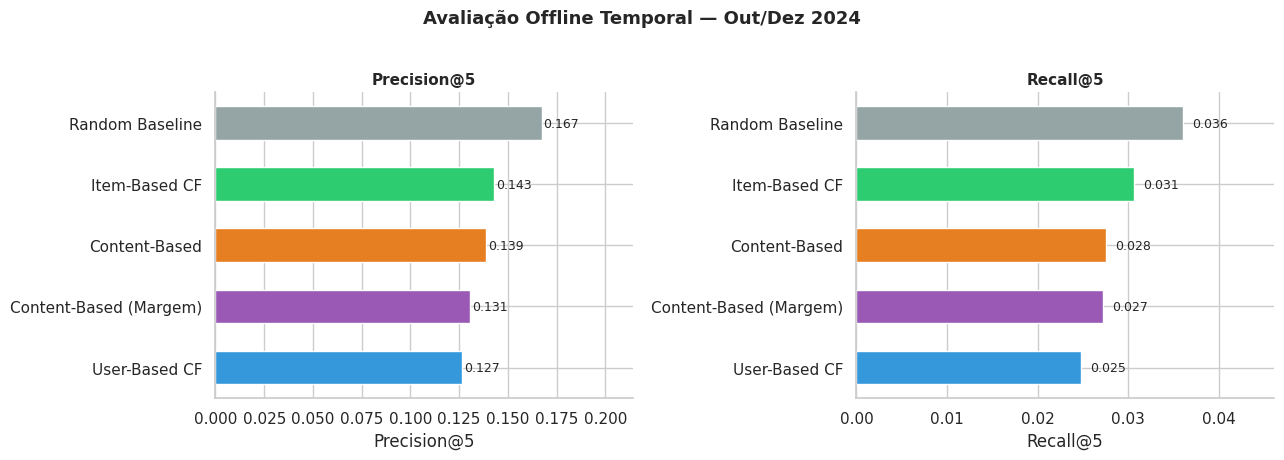

In [0]:
import random

# PARAM: CUTOFF do split temporal de avaliacao offline
# Treino: vendas ate 30/Set/2024 | Teste: vendas Out-Dez/2024
# Out-Dez/2024 = ~25% do periodo, proxy de validacao out-of-time.
# Faixa razoavel: ajustar para mais/menos dados de teste.
# Cuidado: <2 meses de teste fica ruidoso (poucas transacoes por cliente).
CUTOFF = pd.Timestamp('2024-10-01')

vendas_raw = vendas_gold
prod_meta = produtos[['id_product', 'name', 'actual_category']].rename(
    columns={'id_product': 'produto_id', 'name': 'produto_nome', 'actual_category': 'categoria'}
)

train_raw = vendas_raw[vendas_raw['sale_date'] < CUTOFF].copy()
test_raw  = vendas_raw[vendas_raw['sale_date'] >= CUTOFF].copy()

train_inter = (
    train_raw.groupby(['id_client', 'id_product'], as_index=False)['total'].sum()
    .rename(columns={'id_client': 'cliente_id', 'id_product': 'produto_id', 'total': 'receita_total'})
    .merge(prod_meta, on='produto_id', how='left')
)

test_inter = (
    test_raw.groupby(['id_client', 'id_product'], as_index=False)['total'].sum()
    .rename(columns={'id_client': 'cliente_id', 'id_product': 'produto_id', 'total': 'receita_total'})
)

matriz_tr = train_inter.pivot_table(
    index='cliente_id', columns='produto_id', values='receita_total', aggfunc='sum'
).fillna(0)

sim_cli_tr = pd.DataFrame(
    cosine_similarity(matriz_tr), index=matriz_tr.index, columns=matriz_tr.index
)

sim_prod_tr = pd.DataFrame(
    cosine_similarity(matriz_tr.T), index=matriz_tr.columns, columns=matriz_tr.columns
)

pop_tr = (
    train_inter.groupby('produto_id')['receita_total'].mean().reset_index()
    .rename(columns={'receita_total': 'receita_media_geral'})
)

def rec_ub_eval(cliente_id: int, n_similares: int = 5, top_n: int = 5) -> list:
    if cliente_id not in sim_cli_tr.index:
        return []
    similares = (
        sim_cli_tr.loc[cliente_id].drop(cliente_id).sort_values(ascending=False).head(n_similares)
    )
    ja = set(matriz_tr.columns[matriz_tr.loc[cliente_id] > 0])
    scores = {}
    for sim_id, s in similares.items():
        linha = matriz_tr.loc[sim_id]
        for pid, val in linha[linha > 0].items():
            if pid not in ja:
                scores[pid] = scores.get(pid, 0) + s * float(val)
    return [int(pid) for pid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]]

def rec_ib_eval(cliente_id: int, top_n: int = 5) -> list:
    if cliente_id not in matriz_tr.index:
        return []
    ja = set(matriz_tr.columns[matriz_tr.loc[cliente_id] > 0])
    if not ja:
        return []
    scores = {}
    for pid in ja:
        sims = sim_prod_tr.loc[pid].drop(pid).sort_values(ascending=False).head(10)
        for pid2, s in sims.items():
            if pid2 not in ja:
                scores[pid2] = scores.get(pid2, 0) + float(s)
    return [int(pid) for pid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]]

def rec_cb_eval(cliente_id: int, top_n: int = 5) -> list:
    hist = train_inter[train_inter['cliente_id'] == cliente_id]
    if hist.empty:
        return []
    cat_favorita = hist.groupby('categoria')['receita_total'].sum().idxmax()
    ja = set(hist['produto_id'])
    cand = (
        pop_tr.merge(prod_meta, on='produto_id', how='left')
        .query('categoria == @cat_favorita and produto_id not in @ja')
        .sort_values('receita_media_geral', ascending=False)
        .head(top_n)
    )
    return [int(x) for x in cand['produto_id'].tolist()]

def rec_cm_eval(cliente_id: int, top_n: int = 5) -> list:
    """Content-Based ajustado por margem: prioriza maior margem_pct na categoria favorita."""
    hist = train_inter[train_inter['cliente_id'] == cliente_id]
    if hist.empty:
        return []
    cat_favorita = hist.groupby('categoria')['receita_total'].sum().idxmax()
    ja = set(hist['produto_id'])
    cand = (
        margem_produto[
            (margem_produto['categoria'] == cat_favorita) &
            (~margem_produto['produto_id'].isin(ja))
        ]
        .sort_values('margem_pct', ascending=False)
        .head(top_n)
    )
    return [int(x) for x in cand['produto_id'].tolist()]

def rec_random_eval(cliente_id: int, top_n: int = 5) -> list:
    """Baseline aleatório com seed fixa — referência inferior para calibrar as métricas."""
    if cliente_id not in matriz_tr.index:
        return []
    ja = set(matriz_tr.columns[matriz_tr.loc[cliente_id] > 0])
    nao_comprados = [pid for pid in matriz_tr.columns if pid not in ja]
    if len(nao_comprados) <= top_n:
        return [int(p) for p in nao_comprados]
    rng = random.Random(42 + cliente_id)
    return [int(p) for p in rng.sample(nao_comprados, top_n)]

def precision_recall_at_k(rec_list: list, real_set: set, k: int = 5) -> tuple:
    if len(rec_list) == 0:
        return 0.0, 0.0
    rec_k = rec_list[:k]
    hits = len(set(rec_k) & real_set)
    precision = hits / k
    recall = hits / len(real_set) if len(real_set) > 0 else 0.0
    return precision, recall

usuarios_validos = sorted(
    set(train_inter['cliente_id']).intersection(set(test_inter['cliente_id']))
)

METODOS_EVAL = [
    ('User-Based CF',          rec_ub_eval),
    ('Item-Based CF',          rec_ib_eval),
    ('Content-Based',          rec_cb_eval),
    ('Content-Based (Margem)', rec_cm_eval),
    ('Random Baseline',        rec_random_eval),
]

rows_eval = []
for cid in usuarios_validos:
    real_set = set(test_inter[test_inter['cliente_id'] == cid]['produto_id'])
    if not real_set:
        continue
    for metodo, func in METODOS_EVAL:
        kwargs = {'n_similares': 5, 'top_n': 5} if metodo == 'User-Based CF' else {'top_n': 5}
        recs = func(cid, **kwargs)
        p5, r5 = precision_recall_at_k(recs, real_set, k=5)
        rows_eval.append({'cliente_id': cid, 'metodo': metodo, 'precision_at_5': p5, 'recall_at_5': r5})

df_eval = pd.DataFrame(rows_eval)

resumo_eval = (
    df_eval.groupby('metodo')[['precision_at_5', 'recall_at_5']]
    .mean()
    .round(4)
    .sort_values('precision_at_5', ascending=False)
    .reset_index()
)

print('=== AVALIACAO OFFLINE TEMPORAL (OUT-DEZ/2024) ===')
print(f'Cutoff treino/teste: {CUTOFF.date()}')
print(f"Usuarios avaliados : {df_eval['cliente_id'].nunique()}")
print(resumo_eval.to_string(index=False))

# ── Gráfico: Precision@5 e Recall@5 por método ──────────────────────────────
CORES_METODO = {
    'User-Based CF':           '#3498db',
    'Item-Based CF':           '#2ecc71',
    'Content-Based':           '#e67e22',
    'Content-Based (Margem)':  '#9b59b6',
    'Random Baseline':         '#95a5a6',
}
ORDEM_PLOT = resumo_eval.sort_values('precision_at_5', ascending=False)['metodo'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Avaliação Offline Temporal — Out/Dez 2024', fontsize=13, fontweight='bold', y=1.02)

for ax, metrica, titulo in [
    (axes[0], 'precision_at_5', 'Precision@5'),
    (axes[1], 'recall_at_5',    'Recall@5'),
]:
    vals = resumo_eval.set_index('metodo')[metrica].reindex(ORDEM_PLOT).values
    cores = [CORES_METODO[m] for m in ORDEM_PLOT]
    bars = ax.barh(ORDEM_PLOT, vals, color=cores, edgecolor='white', height=0.55)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', ha='left', fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_xlim(0, max(vals) * 1.28)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Perfil de Margem das Recomendações

Com os dados de custo real (câmbio PTAX/BCB), analisamos quais produtos cada abordagem está recomendando em termos de margem — e introduzimos uma variante **ajustada por margem** do Content-Based.

**Pergunta:** o sistema está recomendando produtos que melhoram ou pioram o resultado financeiro?

=== PERFIL DE MARGEM DAS RECOMENDAÇÕES POR MÉTODO ===
 negativa  positiva  risco  total  pct_positiva  pct_risco  pct_negativa
       89        21    135    245           8.6       55.1          36.3
       80        29    136    245          11.8       55.5          32.7
       78        36    131    245          14.7       53.5          31.8


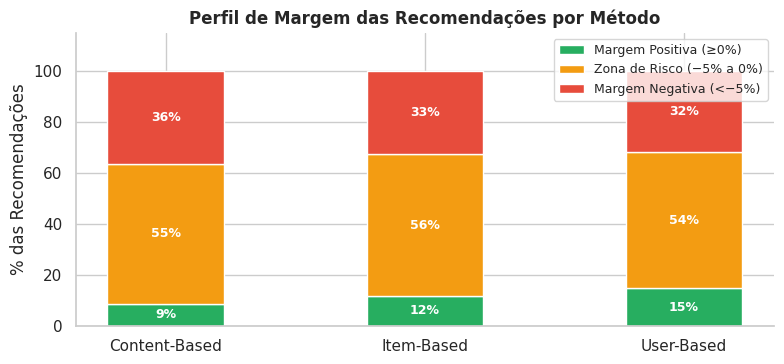


=== MÁRCIA FIGUEIREDO (ID 42) — CONTENT-BASED: ORIGINAL vs AJUSTADO POR MARGEM ===

Original (prioriza receita média):
                              produto_nome categoria  receita_media_geral  margem_pct   status
       Motor Elétrico Torqeedo Pulse 300HP propulsão         2.265752e+06        -7.1 negativa
           Motor de Popa Tohatsu Evo 168HP propulsão         1.782712e+06        -3.1    risco
  Motor de Popa Honda Velocity Drift 258HP propulsão         1.618743e+06        -4.0    risco
      Motor de Popa Volvo Hydro Dash 256HP propulsão         1.576445e+06       -63.2 negativa
Motor de Popa Tohatsu Ion Core Nautic 53HP propulsão         1.482735e+06         2.6 positiva

Ajustado (prioriza maior margem — positiva ou menos negativa):
                                produto_nome categoria  margem_pct   status
            Motor Diesel Tohatsu Zenith 60HP propulsão         5.5 positiva
  Motor de Popa Tohatsu Ion Core Nautic 53HP propulsão         2.6 positiva
          Motor Di

In [0]:
# Gera recomendações para todos os 49 clientes e analisa perfil de margem
all_recs = []
for cid in interacoes['cliente_id'].unique():
    for metodo, func in [
        ('User-Based',    recomendar_user_based),
        ('Item-Based',    recomendar_item_based),
        ('Content-Based', recomendar_content_based),
    ]:
        rec = func(cid)
        if not rec.empty:
            rec = enriquecer_com_margem(rec)
            rec['cliente_id'] = cid
            rec['metodo']     = metodo
            all_recs.append(rec)

df_all = pd.concat(all_recs, ignore_index=True)

# Perfil de margem por método
perfil = (
    df_all
    .groupby(['metodo', 'status'])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
)
for col in ['positiva', 'risco', 'negativa']:
    if col in perfil.columns:
        perfil[f'pct_{col}'] = (perfil[col] / perfil['total'] * 100).round(1)

print('=== PERFIL DE MARGEM DAS RECOMENDAÇÕES POR MÉTODO ===')
print(perfil.to_string(index=False))

# ── Gráfico: Perfil de Margem por Método (stacked bar) ──────────────────────
colunas_pct = [c for c in ['pct_positiva', 'pct_risco', 'pct_negativa'] if c in perfil.columns]
CORES_MARGEM  = {'pct_positiva': '#27ae60', 'pct_risco': '#f39c12', 'pct_negativa': '#e74c3c'}
LABELS_MARGEM = {
    'pct_positiva': 'Margem Positiva (≥0%)',
    'pct_risco':    'Zona de Risco (−5% a 0%)',
    'pct_negativa': 'Margem Negativa (<−5%)',
}

fig, ax = plt.subplots(figsize=(8, 3.8))
bottom = np.zeros(len(perfil))
for col in colunas_pct:
    vals = perfil[col].values if col in perfil.columns else np.zeros(len(perfil))
    bars = ax.bar(perfil.index, vals, bottom=bottom,
                  color=CORES_MARGEM[col], label=LABELS_MARGEM[col], width=0.45)
    for bar, v, b in zip(bars, vals, bottom):
        if v >= 6:
            ax.text(bar.get_x() + bar.get_width() / 2, b + v / 2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 115)
ax.set_ylabel('% das Recomendações')
ax.set_title('Perfil de Margem das Recomendações por Método', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Variante content-based ajustada por margem (menos negativa = menos prejuízo)
def recomendar_content_margem(cliente_id: int, top_n: int = 5) -> pd.DataFrame:
    """
    Variante do Content-Based que prioriza produtos com MELHOR margem
    (positiva ou menos negativa) na categoria favorita do cliente.
    """
    historico = interacoes[interacoes['cliente_id'] == cliente_id]
    if historico.empty:
        return pd.DataFrame()

    cat_favorita = historico.groupby('categoria')['receita_total'].sum().idxmax()
    ja_comprados = set(historico['produto_id'])

    return (
        margem_produto[
            (margem_produto['categoria'] == cat_favorita) &
            (~margem_produto['produto_id'].isin(ja_comprados))
        ]
        .sort_values('margem_pct', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
        .assign(categoria_favorita=cat_favorita)
    )

# Comparativo para Márcia Figueiredo (top cliente por receita)
print('\n=== MÁRCIA FIGUEIREDO (ID 42) — CONTENT-BASED: ORIGINAL vs AJUSTADO POR MARGEM ===')

print('\nOriginal (prioriza receita média):')
cb_orig = enriquecer_com_margem(recomendar_content_based(42))
safe_print(cb_orig[['produto_nome', 'categoria', 'receita_media_geral', 'margem_pct', 'status']] if not cb_orig.empty else cb_orig.to_string(index=False))

print('\nAjustado (prioriza maior margem — positiva ou menos negativa):')
safe_print(recomendar_content_margem(42)[['produto_nome', 'categoria', 'margem_pct', 'status']])

n_pos_cat = margem_produto[margem_produto['status'] == 'positiva'].shape[0]
print(f'\nInsight: {n_pos_cat}/150 produtos têm margem positiva com o câmbio atual.')
print('O sistema ajustado prioriza esses produtos — menor impacto no resultado ao recomendar.')

## 8. Resumo Executivo

### Para o Gabriel (Tech Lead)
Cinco abordagens implementadas sem bibliotecas especializadas — apenas `pandas` e `sklearn.cosine_similarity`. O perfil de margem das recomendações (Seção 7) reutiliza a mesma CTE de vigência temporal de custo das Etapas 3 e 4. A variante `recomendar_content_margem()` prioriza produtos pelo critério de maior margem (positiva ou menos negativa) — ponto de partida para precificação baseada em dados.

**Avaliação offline temporal (Seção 6.1) — cutoff Out/2024, 49 usuários avaliados:**

| Método | Precision@5 | Recall@5 |
|---|---|---|
| **Random Baseline** | **0,167** | **0,036** |
| Item-Based CF | 0,143 | 0,031 |
| Content-Based | 0,139 | 0,028 |
| Content-Based (Margem) | 0,131 | 0,027 |
| User-Based CF | 0,127 | 0,025 |

**Achado técnico crítico:** o Random Baseline (0,167) supera todos os métodos CF. Isso não é falha dos algoritmos — é consequência direta da densidade de 73,6%. Com a maioria dos clientes tendo comprado ~73% do catálogo, qualquer produto não comprado tem alta probabilidade de ser comprado no próximo trimestre, incluindo uma escolha aleatória. Nesse regime, Precision@5 não discrimina bem os métodos. O valor do sistema **não está em acertar mais**: está em *qual* produto recomendar — com margem positiva ou negativa faz toda a diferença para o resultado financeiro.

### Para a Marina (Gerente de Negócios)
| Métrica | Valor |
|---|---|
| Clientes cobertos | 49/49 (100%) — todos os 3 métodos |
| Densidade da matriz | 73,6% — catálogo amplamente explorado |
| Produtos com margem positiva | **23/150** no histórico com câmbio variável do dia |
| Produtos em zona de risco (−5% a 0%) | 75/150 |
| Produtos com margem negativa (< −5%) | 51/150 |

**Perfil de margem das recomendações geradas:**
| Método | % Positiva | % Risco | % Negativa |
|---|---|---|---|
| User-Based CF | 14,7% | 53,5% | 31,8% |
| Item-Based CF | 11,8% | 55,5% | 32,7% |
| Content-Based | 8,6% | 55,1% | 36,3% |

**Implicação:** como os métodos acertam igualmente bem o que o cliente vai comprar, a escolha do método deve ser guiada pelo perfil de margem das recomendações, não pela Precision@5. A **variante ajustada por margem** (`recomendar_content_margem`) garante que as recomendações priorizam os 24 produtos positivos — único cenário em que vender mais gera resultado positivo com o câmbio atual.

**Sequência recomendada:**
1. Usar variante por margem agora — direciona para os 24 produtos positivos primeiro
2. Após reajuste de preços — voltar ao sistema original (receita + convergência) para maximizar volume
3. Prioridade máxima: produtos que aparecem nas 3 abordagens **E** têm margem positiva ou menos negativa

### Para o Sr. Almir (Fundador)
O sistema sabe o que cada cliente ainda não comprou e o que clientes parecidos compraram. Dos 150 produtos, **24 já têm margem positiva** — vender esses produtos gera lucro real, mesmo com o dólar alto. O sistema ajustado direciona as recomendações exatamente para esses 23 produtos. Enquanto os preços dos outros 126 não forem corrigidos, essas são as campanhas que fazem sentido rodar. Depois do reajuste geral, o sistema de recomendação se torna uma ferramenta poderosa para crescer com toda a margem positiva.

In [0]:
def run_all_quality_checks_recomendacao(inter_df, matriz_df, top5_df, cobertura_tuple, eval_df):
    """Checks críticos de consistência da Etapa 6."""
    cobertura_ub_local, cobertura_ib_local, cobertura_cb_local, total_clientes_local = cobertura_tuple
    checks = {
        'interacoes_com_colunas_criticas': set(['cliente_id', 'produto_id', 'receita_total']).issubset(inter_df.columns),
        'matriz_cliente_produto_nao_vazia': matriz_df.shape[0] > 0 and matriz_df.shape[1] > 0,
        'top5_clientes_ok': len(top5_df) == 5,
        'cobertura_user_based_total': cobertura_ub_local == total_clientes_local,
        'cobertura_item_based_total': cobertura_ib_local == total_clientes_local,
        'cobertura_content_based_total': cobertura_cb_local == total_clientes_local,
        'avaliacao_offline_disponivel': not eval_df.empty and set(['metodo', 'precision_at_5', 'recall_at_5']).issubset(eval_df.columns),
    }
    qa = pd.DataFrame({'check': checks.keys(), 'status': checks.values()})
    qa['resultado'] = qa['status'].map({True: 'PASS', False: 'FAIL'})
    return qa

total_clientes = len(todos_clientes)
qa_recomendacao = run_all_quality_checks_recomendacao(
    interacoes,
    matriz,
    top5_clientes,
    (cobertura_ub, cobertura_ib, cobertura_cb, total_clientes),
    df_eval
 )
print(qa_recomendacao[['check', 'resultado']].to_string(index=False))

if qa_recomendacao['status'].all():
    print('RUN_ALL CHECKS (ETAPA 6): PASS')
else:
    print('RUN_ALL CHECKS (ETAPA 6): FAIL')

                           check resultado
 interacoes_com_colunas_criticas      PASS
matriz_cliente_produto_nao_vazia      PASS
                top5_clientes_ok      PASS
      cobertura_user_based_total      PASS
      cobertura_item_based_total      PASS
   cobertura_content_based_total      PASS
    avaliacao_offline_disponivel      PASS
RUN_ALL CHECKS (ETAPA 6): PASS
